### Configs e Libs

In [4]:
!pip install langgraph langchain ipython langchain_openai langchain_community dotenv typing chromadb langchain_chroma


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import getpass
import os

def _set_env(key: str):
    if key not in os.environ:
        os.environ[key] = getpass.getpass(f"{key}:")


_set_env("OPENAI_API_KEY")

## Lesson 1: Create Agent

### Tools

In [5]:
from langchain.tools import tool

@tool
def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"

In [6]:
tools = [get_weather]

### Agent

In [7]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from IPython.display import Image, display

In [8]:
system_prompt = "You are a helpful assistant. Be concise and accurate."

In [83]:
model = ChatOpenAI(
    model="gpt-4o-mini-2024-07-18",
    temperature=0.1,
    max_tokens=1000,
    timeout=30
)

Create agent

In [10]:
agent = create_agent(model=model, system_prompt=system_prompt, tools=tools)

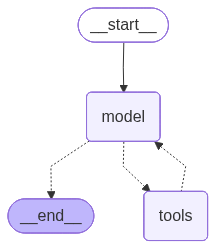

In [11]:
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

### Dynamic model

In [ ]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse

In [ ]:
basic_model = model
advanced_model = ChatOpenAI(model="gpt-4o")

In [ ]:
@wrap_model_call # Envolver e interceptar chamadas de modelo
def dynamic_model_selection(request: ModelRequest, handler) -> ModelResponse:
    """Choose model based on conversation complexity."""
    message_count = len(request.state["messages"])

    if message_count > 10:
        # Usar um modelo mais avançado para conversas longas
        model = advanced_model
    else:
        model = basic_model

    request.model = model
    return handler(request)

In [ ]:
agent_dynamic_model = create_agent(
    model=basic_model,  # Default model
    tools=tools,
    middleware=[dynamic_model_selection]
)

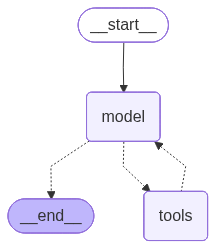

In [ ]:
display(Image(agent_dynamic_model.get_graph(xray=True).draw_mermaid_png()))

### Tools

In [23]:
from langchain.tools import BaseTool

Custom tool name

In [24]:
@tool("web_search")
def search(query: str) -> str:
    """Search the web for information."""
    return f"Results for: {query}"

In [25]:
tools.append(search)


Custom tool description

In [ ]:
@tool("calculator", description="Performs arithmetic calculations. Use this for any math problems.")
def calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    return str(eval(expression))

In [ ]:
tools.append(calc)


Advanced schema definition

In [26]:
from pydantic import BaseModel, Field
from typing import Literal

class WeatherInput(BaseModel):
    """Input for weather queries."""
    location: str = Field(description="City name or coordinates")
    units: Literal["celsius", "fahrenheit"] = Field(
        default="celsius",
        description="Temperature unit preference"
    )
    include_forecast: bool = Field(
        default=False,
        description="Include 5-day forecast"
    )

@tool(args_schema=WeatherInput)
def get_weather(location: str, units: str = "celsius", include_forecast: bool = False) -> str:
    """Get current weather and optional forecast."""
    temp = 22 if units == "celsius" else 72
    result = f"Current weather in {location}: {temp} degrees {units[0].upper()}"
    if include_forecast:
        result += "\nNext 5 days: Sunny"
    return result

In [27]:
tools.append(get_weather)

In [28]:
question_1 = "What is the weather in New York?"

In [29]:
for step in agent.stream(
 {"messages": question_1},
 stream_mode="values",
):
 step["messages"][-1].pretty_print()

================================ Human Message =================================

What is the weather in New York?


AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: AIzaSyBJ***************************S2pI. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}

In [ ]:
question_2 = "What is 2+2?"

In [ ]:
for step in agent.stream(
 {"messages": question_2},
 stream_mode="values",
):
 step["messages"][-1].pretty_print()

================================ Human Message =================================

What is 2+2?
================================== Ai Message ==================================
Tool Calls:
  calculator (call_RifmDOW9asGtCItIyDsNEaME)
 Call ID: call_RifmDOW9asGtCItIyDsNEaME
  Args:
    expression: 2+2
================================= Tool Message =================================
Name: calculator

4
================================== Ai Message ==================================

2+2 is 4.


In [ ]:
result = agent.invoke(
    {"messages": [{"role": "user", "content": "What's the weather in San Francisco?"}]}
)

In [ ]:
result

{'messages': [HumanMessage(content="What's the weather in San Francisco?", additional_kwargs={}, response_metadata={}, id='365eff92-0b87-4477-9c91-09ec92654e3d'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_CNA7Kta0Sdfx5Rxlux5Bj3LJ', 'function': {'arguments': '{"location":"San Francisco"}', 'name': 'get_weather'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 146, 'total_tokens': 161, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4c2851f862', 'id': 'chatcmpl-CcxfkRmfq8M5PhgEcWeSBK06OhO4v', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--0b529c8e-7a0c-468e-a6aa-a86e953f9c3d-0', tool_calls=[{'name': 'get_weather', 'args': {'loca

## Advanced concepts


### ToolStrategy

In [ ]:
class ContactInfo(BaseModel):
    name: str

In [ ]:
from langchain.agents.structured_output import ToolStrategy

agent_ToolStrategy = create_agent(model=model, system_prompt=system_prompt, tools=tools, response_format=ToolStrategy(ContactInfo))

In [ ]:
result = agent.invoke({
    "messages": [{"role": "user", "content": "Search contact info from: John Doe, john@example.com, (555) 123-4567"}]
})

In [ ]:
result

{'messages': [HumanMessage(content='Search contact info from: John Doe, john@example.com, (555) 123-4567', additional_kwargs={}, response_metadata={}, id='e2c32fb8-6a2d-4002-8959-33b6afcff493'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_tZsUsNrvJSVYOGRMdXJsVEiF', 'function': {'arguments': '{"query":"John Doe contact information"}', 'name': 'web_search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 159, 'total_tokens': 176, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4c2851f862', 'id': 'chatcmpl-CcxjfaBD7kM9piC5CpifnXPFADasr', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--a7450cb5-10ff-4ff7-b5b6-084fe2277a4f-0', tool_ca

In [ ]:
for step in agent.stream(
 {"messages": "Search contact info from: John Doe, john@example.com, (555) 123-4567"},
 stream_mode="values",
):
 step["messages"][-1].pretty_print()

================================ Human Message =================================

Search contact info from: John Doe, john@example.com, (555) 123-4567
================================== Ai Message ==================================
Tool Calls:
  web_search (call_zJZqNWUNfhOJAVU6qNnx7Igw)
 Call ID: call_zJZqNWUNfhOJAVU6qNnx7Igw
  Args:
    query: John Doe contact information
================================= Tool Message =================================
Name: web_search

Results for: John Doe contact information
================================== Ai Message ==================================

I searched for contact information for John Doe but did not find any additional details beyond what you provided: john@example.com and (555) 123-4567. Is there anything specific you would like me to do with this information?


In [ ]:
from langchain.agents.middleware import dynamic_prompt, ModelRequest

In [ ]:
from typing import TypedDict

class Context(TypedDict):
    user_role: str

In [ ]:
@dynamic_prompt
def user_role_prompt(request: ModelRequest) -> str:
    """Generate system prompt based on user role."""
    user_role = request.runtime.context.get("user_role", "user")
    base_prompt = "You are a helpful assistant."

    if user_role == "expert":
        return f"{base_prompt} Provide detailed technical responses."
    elif user_role == "beginner":
        return f"{base_prompt} Explain concepts simply and avoid jargon."

    return base_prompt

In [ ]:
agent_with_dynamic_prompt = create_agent(model=model, system_prompt=system_prompt, tools=tools, middleware=[user_role_prompt], context_schema=Context)

In [ ]:
# The system prompt will be set dynamically based on context
result = agent_with_dynamic_prompt.invoke(
    {"messages": [{"role": "user", "content": "Explain machine learning"}]},
    context={"user_role": "expert"}
)

In [ ]:
result['messages'][-1].content

'Machine learning is a branch of artificial intelligence (AI) that focuses on building systems that can learn from and make decisions based on data. Instead of being explicitly programmed to perform a task, machine learning algorithms use statistical techniques to identify patterns in data and improve their performance on a specific task over time.\n\nKey concepts in machine learning include:\n\n1. Data: The raw information used to train the model. This can be anything from numbers and text to images and audio.\n\n2. Model: A mathematical representation or algorithm that processes the data to make predictions or decisions.\n\n3. Training: The process of feeding data into the model so it can learn patterns and relationships.\n\n4. Features: The individual measurable properties or characteristics of the data used for training.\n\n5. Labels: The correct output or answer used in supervised learning to guide the model.\n\n6. Types of Machine Learning:\n   - Supervised Learning: The model is

In [ ]:
# The system prompt will be set dynamically based on context
result = agent.invoke(
    {"messages": [{"role": "user", "content": "Explain machine learning"}]},
    context={"user_role": "beginner"}
)

In [ ]:
result['messages'][-1].content

'Machine learning is a branch of artificial intelligence (AI) that focuses on building systems that can learn from and make decisions based on data. Instead of being explicitly programmed to perform a task, machine learning algorithms use statistical techniques to identify patterns in data and improve their performance over time with experience.\n\nKey concepts in machine learning include:\n\n1. Data: The raw information used to train the model. This can be anything from numbers and text to images and audio.\n\n2. Model: A mathematical representation or algorithm that processes the data to make predictions or decisions.\n\n3. Training: The process of feeding data into the model so it can learn patterns and relationships.\n\n4. Features: Individual measurable properties or characteristics of the data used for training.\n\n5. Labels: The output or target variable that the model aims to predict (used in supervised learning).\n\n6. Types of Learning:\n   - Supervised Learning: The model is

In [ ]:
from typing import TypedDict

class Context(TypedDict):
    language: str

In [ ]:
@dynamic_prompt
def user_language_prompt(request: ModelRequest) -> str:
    """Generate system prompt based on user language."""
    language = request.runtime.context.get("language", "language")
    base_prompt = "You are a helpful assistant."

    if language == "pt-BR":
        return f"{base_prompt} You should respond in Brazilian Portuguese."
    else:
        return f"{base_prompt} You should respond in English."

In [ ]:
agent_with_dynamic_language = create_agent(model=model, system_prompt=system_prompt, tools=tools, middleware=[user_language_prompt], context_schema=Context)

In [ ]:
# The system prompt will be set dynamically based on context
result = agent_with_dynamic_language.invoke(
    {"messages": [{"role": "user", "content": "Explain machine learning"}]},
    context={"language": "pt-BR"}
)

In [ ]:
result['messages'][-1].content

'Machine learning, ou aprendizado de máquina, é uma área da inteligência artificial que desenvolve algoritmos e técnicas que permitem aos computadores aprenderem a partir de dados e melhorarem seu desempenho em tarefas específicas sem serem explicitamente programados para isso. Em vez de seguir regras fixas, os sistemas de machine learning identificam padrões nos dados e fazem previsões ou decisões baseadas nesses padrões.\n\nExistem três principais tipos de aprendizado em machine learning:\n\n1. Aprendizado Supervisionado: O modelo é treinado com um conjunto de dados rotulado, ou seja, com exemplos de entrada e saída desejada. O objetivo é que o modelo aprenda a mapear entradas para saídas corretas.\n\n2. Aprendizado Não Supervisionado: O modelo trabalha com dados não rotulados e tenta encontrar estruturas ou padrões ocultos, como agrupamentos ou associações.\n\n3. Aprendizado por Reforço: O modelo aprende a tomar decisões sequenciais através de recompensas e punições, buscando maximi

In [ ]:
result = agent_with_dynamic_language.invoke(
    {"messages": [{"role": "user", "content": "Explain machine learning"}]},
    context={"language": "en-US"}
)

In [ ]:
result['messages'][-1].content

'Machine learning is a branch of artificial intelligence (AI) that focuses on building systems that can learn from and make decisions or predictions based on data. Instead of being explicitly programmed to perform a task, machine learning algorithms use statistical techniques to identify patterns in data and improve their performance over time with experience.\n\nKey concepts in machine learning include:\n\n1. Data: The raw information used to train the model. This can be anything from numbers and text to images and sounds.\n2. Model: A mathematical representation or algorithm that processes the data to make predictions or decisions.\n3. Training: The process of feeding data into the model so it can learn the underlying patterns.\n4. Features: Individual measurable properties or characteristics of the data used for training.\n5. Labels: The output or target variable that the model aims to predict (used in supervised learning).\n6. Types of Learning:\n   - Supervised Learning: The model

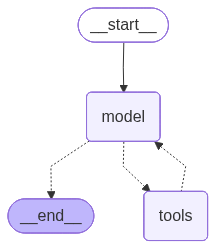

In [ ]:
display(Image(agent_with_dynamic_language.get_graph(xray=True).draw_mermaid_png()))

In [16]:
@tool
def multiply(a: int, b: int) -> int:
 """Multiply two numbers.
  Args:
    a (int): The first number to multiply.
    b (int): The second number to multiply.
  Returns:
    int: The product of the two input numbers.
 """
 # Perform the multiplication and return the result
 return a * b

In [17]:
tools.append(multiply)

In [16]:
tools

[StructuredTool(name='get_weather', description='Get weather for a given city.', args_schema=<class 'langchain_core.utils.pydantic.get_weather'>, func=<function get_weather at 0x7efb409a24d0>),
 StructuredTool(name='multiply', description='Multiply two numbers.\n  Args:\n    a (int): The first number to multiply.\n    b (int): The second number to multiply.\n  Returns:\n    int: The product of the two input numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x7efa944b5870>)]

### Memory

Defining state via middleware

In [25]:
from langchain.agents import AgentState
from langchain.agents.middleware import AgentMiddleware
from typing import Any

In [24]:
class CustomState(AgentState):
    user_preferences: dict

In [26]:
class CustomMiddleware(AgentMiddleware):
    state_schema = CustomState

    def before_model(self, state: CustomState, tools) -> dict[str, Any] | None:
        pass

In [ ]:
agent_CustomState = create_agent(
    model,
    tools=tools,
    middleware=[CustomMiddleware()]
)

In [30]:
result = agent_CustomState.invoke({
    "messages": [{"role": "user", "content": "I prefer technical explanations"}],
    "user_preferences": {"style": "technical", "verbosity": "detailed", "language": "pt-BR"},
})

In [ ]:
result['messages'][-1].content

"Sure! Please specify the topic or concept you'd like a technical explanation about, and I'll provide a detailed response."

## Format Response

In [31]:
from typing_extensions import TypedDict


class UserInfos(TypedDict):
  name: str

In [20]:
agent = create_agent(model, tools=tools, response_format=UserInfos)

In [ ]:
result = agent.invoke({
    "messages": [{"role": "user", "content": "My name is Wanderson Fontes i'm a software engineer and you?"}]
})

In [ ]:
result['messages'][-1].content

"Returning structured response: {'name': 'Wanderson Fontes'}"

In [ ]:
result['structured_response']

{'name': 'Wanderson Fontes'}

## Middleware

### Hooks de Nó (Node Hooks)

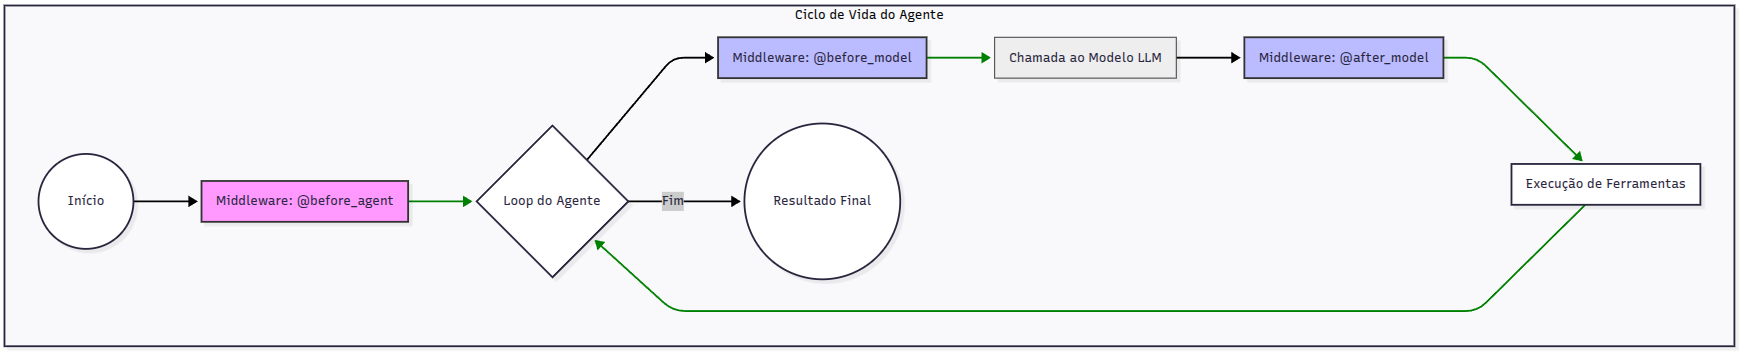

Executam antes ou depois de um nó principal (antes do agente começar, antes/depois de chamar o modelo).

Exemplos: `@before_agent`, `@before_model`, `@after_model`.

In [12]:
from langchain.agents.middleware import before_agent, before_model, after_model, \
  after_agent, hook_config, AgentState, AgentMiddleware
from langchain.messages import AIMessage
from langgraph.runtime import Runtime
from typing import Any

Decorator

In [13]:
@before_agent
def log_before_agent(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    print("before_agent")
    return None

In [14]:
@before_model
def log_before_model(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    print("before_model")
    return None

In [15]:
@after_model
def log_after_model(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
  print("after_model")
  return None

In [16]:
agent_decorator_middleware = create_agent(model, tools=tools, middleware=[log_before_agent, log_before_model, log_after_model])

In [17]:
result = agent_decorator_middleware.invoke(
    {"messages": [{"role": "user", "content": "What's the weather in San Francisco?"}]}
)

before_agent
before_model
after_model
before_model
after_model


Class


In [66]:
class MyFristMiddleware(AgentMiddleware):
    def __init__(self):
        super().__init__()

    def before_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        print("MyFristMiddleware: before_agent")
        return None

    def before_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        print("MyFristMiddleware:  before_model")
        return None

    def after_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        print("MyFristMiddleware:  after_model")
        return None

    def after_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        print("MyFristMiddleware:  after_agent")
        return None

In [51]:
agent_class_middleware = create_agent(model, tools=tools, middleware=[MyFristMiddleware()])

In [52]:
result = agent_class_middleware.invoke(
    {"messages": [{"role": "user", "content": "What's the weather in San Francisco?"}]}
)

MyFristMiddleware: before_agent


AI Agent com N middlewares

In [53]:
class MySecondMiddleware(AgentMiddleware):
    def __init__(self):
        super().__init__()

    def before_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        print("MySecondMiddleware: before_agent second")
        return None

In [54]:
agent_class_middleware = create_agent(model, tools=tools, middleware=[MyFristMiddleware(), MySecondMiddleware()])

In [55]:
result = agent_class_middleware.invoke(
    {"messages": [{"role": "user", "content": "What's the weather in San Francisco?"}]}
)

MyFristMiddleware: before_agent
MySecondMiddleware: before_agent second


In [59]:
class MyThirdMiddleware(AgentMiddleware):
    def __init__(self):
        super().__init__()

    def before_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        print("MyThirdMiddleware: before_agent third")
        return None

In [67]:
agent_class_middleware = create_agent(model, tools=tools, middleware=[MyFristMiddleware(), MySecondMiddleware(), MyThirdMiddleware()])

In [68]:
result = agent_class_middleware.invoke(
    {"messages": [{"role": "user", "content": "What's the weather in San Francisco?"}]}
)

MyFristMiddleware: before_agent
MySecondMiddleware: before_agent second
MyThirdMiddleware: before_agent third
MyFristMiddleware:  before_model
MyFristMiddleware:  after_model
MyFristMiddleware:  before_model
MyFristMiddleware:  after_model
MyFristMiddleware:  after_agent


In [74]:
class MyFourMiddleware(AgentMiddleware):
    def __init__(self):
        super().__init__()

    def after_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        print("MyFourMiddleware: after_agent fourth")
        return None

In [75]:
agent_class_middleware = create_agent(model, tools=tools, middleware=[MyFristMiddleware(), MySecondMiddleware(), MyThirdMiddleware(), MyFourMiddleware()])

In [76]:
result = agent_class_middleware.invoke(
    {"messages": [{"role": "user", "content": "What's the weather in San Francisco?"}]}
)

MyFristMiddleware: before_agent
MySecondMiddleware: before_agent second
MyThirdMiddleware: before_agent third
MyFristMiddleware:  before_model
MyFristMiddleware:  after_model
MyFristMiddleware:  before_model
MyFristMiddleware:  after_model
MyFourMiddleware: after_agent fourth
MyFristMiddleware:  after_agent


### Hooks Interceptores (Interceptor Hooks)

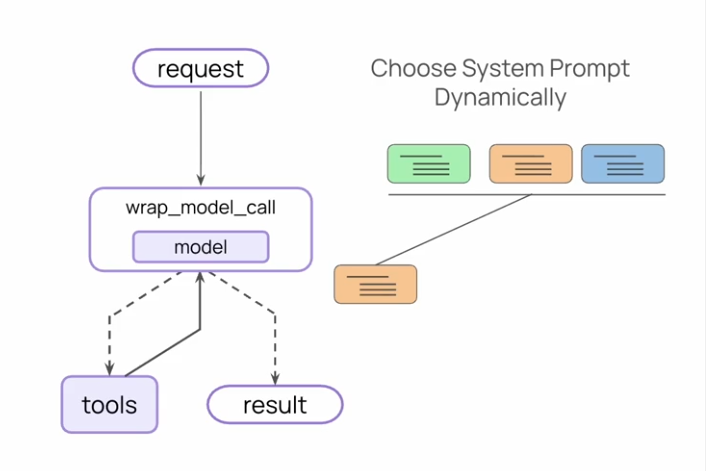

In [92]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable


class MyWarpModelCallMiddleware(AgentMiddleware):
    def __init__(self):
        super().__init__()

    def wrap_model_call(self, request: ModelRequest, handler: Callable) -> ModelResponse | None:
        print("MyWarpModelCallMiddleware: wrap_model_call")
        return None
    
    def after_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        print("MyWarpModelCallMiddleware: after_agent fourth")
        return None

In [93]:
agent_class_middleware = create_agent(
    model, 
    tools=tools, 
    middleware=[MyWarpModelCallMiddleware()])

In [94]:
agent_class_middleware.invoke(
    {"messages": [{"role": "user", "content": "What's the weather in San Francisco?"}]}
)

MyWarpModelCallMiddleware: wrap_model_call


AttributeError: 'NoneType' object has no attribute 'result'

In [71]:
result = agent_class_middleware.invoke({
    "messages": [{"role": "user", "content": "My name is Wanderson Fontes i'm a software engineer and you?"}]
})

before_agent
before_agent second
before_model
wrap_model_call


AttributeError: 'NoneType' object has no attribute 'result'